# All statments with their relevant statistical tests

## Introduction

### Number of Variants with dTM > 5 C

In [1]:
import pandas as pd

tsa_summary = pd.read_csv('../Data/Figure3/TSA_summary_round3.csv')
wt_list = ['MGYP001421927114', 'A0A372IUB3', 'A0A2S1LEZ1']
tm_medians = tsa_summary.groupby("#Annotation", as_index=False)["#Tm"].median()

tm_medians["wt_id"] = tm_medians["#Annotation"].str.split("_", n=1).str[0]
lineage_tm_medians = tm_medians.loc[tm_medians['wt_id'].isin(wt_list)].copy()
n_variants_total = lineage_tm_medians.loc[~lineage_tm_medians['#Annotation'].isin(wt_list)].shape[0]


wildtype_tm = tm_medians.set_index("#Annotation")["#Tm"]
lineage_tm_medians["dTM"] = lineage_tm_medians["#Tm"] - lineage_tm_medians["wt_id"].map(wildtype_tm)
variants_above_5c = lineage_tm_medians.loc[lineage_tm_medians["dTM"] >= 5]
n_variants = variants_above_5c.shape[0]

print(f"Number of variants with dTM >= 5: {n_variants}")
print(f"Percentage of variants with dTM >= 5: {n_variants / n_variants_total * 100:.2f}%")

Number of variants with dTM >= 5: 19
Percentage of variants with dTM >= 5: 70.37%


## Retain activity above WT TM

In [24]:
from Bio import SeqIO

df_round3_sequences = {"id":[], "seq":[], "wt_id":[]}
for rec in SeqIO.parse("../Data/Figure3/round3_sequences_all.fasta", "fasta"):
    df_round3_sequences["id"].append(rec.id)
    df_round3_sequences["seq"].append(str(rec.seq))
    df_round3_sequences["wt_id"].append(rec.id.split("_")[0])
df_round3_sequences = pd.DataFrame(df_round3_sequences)

In [25]:
variant_count_df = df_round3_sequences.groupby("wt_id").agg({"id":"count"}).rename(columns={"id":"n_variants"}).reset_index()
print(f"Number of variants Total: {variant_count_df['n_variants'].sum() - 5 }") # 5 is wildtypes
print(f"Number of variants with active wildtype reference: {variant_count_df['n_variants'].sum() - 9 }") # 5 is wildtypes and 4 is variants from inactive wildtype

Number of variants Total: 39
Number of variants with active wildtype reference: 35


In [26]:
from Helpers.helper_figure3 import compile_activity_resistance
from Helpers.helper_statements import summarize_activity_retention_above_wt_tm

# Match the Figure 3 activity definition: corrected initial rate through 540 s,
# expressed relative to each sample's activity after treatment at 50 °C.
_, activity_summary, _ = compile_activity_resistance(
    '../Data/Figure3',
    fit_until_s=540,
    reference_mode='temperature',
    reference_temperature=50,
)

# Retention means >= 50% relative activity at any measured temperature
# strictly above the median melting temperature of the corresponding WT.
variant_activity_above_wt_tm, activity_retention_summary = (
    summarize_activity_retention_above_wt_tm(
        activity_summary,
        tsa_summary,
        retained_activity_threshold=50,
    )
)

display(activity_retention_summary)
total_variants_with_active_wt = variant_count_df['n_variants'].sum() - 9 

print("fraction of variants with active wildtype reference that retain activity above the median Tm of the corresponding wildtype: ", activity_retention_summary["n_variants_retaining_activity_above_wt_tm"].values / total_variants_with_active_wt)


,n_variants_with_measurements_above_wt_tm,n_variants_retaining_activity_above_wt_tm,fraction_variants_retaining_activity_above_wt_tm,percent_variants_retaining_activity_above_wt_tm,retained_activity_threshold_percent
0,26,20,0.769231,76.923077,50.0


fraction of variants with active wildtype reference that retain activity above the median Tm of the corresponding wildtype:  [0.57142857]


In [32]:
n_variants = variant_activity_above_wt_tm.shape[0]
n_variants_active_above_WT = variant_activity_above_wt_tm.loc[variant_activity_above_wt_tm["wildtype_id"] == "A0A372IUB3"]["retains_activity_above_wt_tm"].sum()
print(f"Number of variants with active wildtype reference that retain activity above the median Tm of the corresponding wildtype: {n_variants_active_above_WT} out of {n_variants} ({n_variants_active_above_WT / n_variants * 100:.2f}%)")

Number of variants with active wildtype reference that retain activity above the median Tm of the corresponding wildtype: 14 out of 26 (53.85%)


A variant is counted as retaining activity above its wild-type melting point when it has at least 50% relative activity at one or more measured treatment temperatures strictly above the median WT melting temperature. Relative activity uses the same definition as Figure 3: the negative-control-corrected initial rate (fit through 540 s), normalized to that sample's activity after the 50 °C treatment.

### Maximum temperature with retained activity versus melting temperature

For each variant represented in both assays, the maximum treatment temperature with at least 50% relative activity is compared with its median TSA melting temperature. Spearman correlation is reported as the primary statistic because treatment temperature is sampled at discrete levels; Pearson correlation is also shown for reference.

In [ ]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# Analysis and plot settings
retained_activity_threshold = 50
size_mm = (90, 75)  # width, height
font_size = 7

# Retain variants only and find the highest assayed temperature at which
# each variant has at least the specified relative activity.
variant_activity = activity_summary.loc[
    activity_summary['sample_name'] != activity_summary['wildtype_id']
].copy()
retained_measurements = variant_activity.loc[
    variant_activity['percent_active'] >= retained_activity_threshold
].copy()
maximum_retained_temperature = (
    retained_measurements
    .groupby(['sample_name', 'wildtype_id'], as_index=False)
    .agg(maximum_retained_temperature_c=('temperature_c', 'max'))
)

# Use the median Tm when the TSA assay contains replicate measurements.
variant_tm = (
    tsa_summary.loc[:, ['#Annotation', '#Tm']]
    .assign(**{'#Tm': lambda frame: pd.to_numeric(frame['#Tm'], errors='coerce')})
    .groupby('#Annotation', as_index=False)['#Tm'].median()
    .rename(columns={'#Annotation': 'sample_name', '#Tm': 'median_tm_c'})
)

activity_tm_correlation = (
    maximum_retained_temperature
    .merge(variant_tm, on='sample_name', how='inner')
    .dropna(subset=['median_tm_c', 'maximum_retained_temperature_c'])
    .sort_values(['wildtype_id', 'sample_name'])
    .reset_index(drop=True)
)

if len(activity_tm_correlation) < 3:
    raise ValueError('At least three variants with both activity and TSA data are required.')

spearman_result = spearmanr(
    activity_tm_correlation['median_tm_c'],
    activity_tm_correlation['maximum_retained_temperature_c'],
)
pearson_result = pearsonr(
    activity_tm_correlation['median_tm_c'],
    activity_tm_correlation['maximum_retained_temperature_c'],
)

print(f"Variants included: {len(activity_tm_correlation)}")
print(f"Spearman rho = {spearman_result.statistic:.3f}, p = {spearman_result.pvalue:.3g}")
print(f"Pearson r = {pearson_result.statistic:.3f}, p = {pearson_result.pvalue:.3g}")
display(activity_tm_correlation)

activity_tm_correlation.to_csv(
    '../Results/Statements/variant_tm_maximum_retained_activity_temperature.csv',
    index=False,
)

fig, ax = plt.subplots(figsize=tuple(value / 25.4 for value in size_mm))
sns.regplot(
    data=activity_tm_correlation,
    x='median_tm_c',
    y='maximum_retained_temperature_c',
    scatter=False,
    color='0.3',
    line_kws={'linewidth': 1},
    ax=ax,
)
sns.scatterplot(
    data=activity_tm_correlation,
    x='median_tm_c',
    y='maximum_retained_temperature_c',
    hue='wildtype_id',
    palette='viridis',
    s=22,
    edgecolor='white',
    linewidth=0.4,
    ax=ax,
)
ax.set_xlabel('Median melting temperature (°C)', fontsize=font_size)
ax.set_ylabel('Maximum temperature with ≥50% activity (°C)', fontsize=font_size)
ax.tick_params(labelsize=font_size)
ax.text(
    0.03,
    0.97,
    f"Spearman ρ = {spearman_result.statistic:.2f}\np = {spearman_result.pvalue:.2g}",
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=font_size,
)
legend = ax.legend(title='WT lineage', fontsize=font_size, title_fontsize=font_size)
fig.tight_layout()
fig.savefig(
    '../Results/Statements/variant_tm_vs_maximum_retained_activity_temperature.pdf',
    bbox_inches='tight',
)
plt.show()

Variants that retain at least 50% activity at the highest assayed temperature are right-censored: their true maximum retained-activity temperature may be higher than the value shown. Variants without any qualifying retained-activity measurement are excluded from the correlation.

## Sequence similarity Thermophiles and mesophiles within ortoloughes

In [6]:
import importlib
from Helpers import helper_statements

# Reload so edits to the helper are picked up in an already-running kernel.
importlib.reload(helper_statements)

cog_sequence_identity, overall_sequence_identity = (
    helper_statements.summarize_cog_thermophile_mesophile_identity(
        '../Data/Figure1/meltome_atlas.fasta',
        '../Data/Figure1/meltome_atlas_annot.emapper.annotations',
        thermophile_temperature=60,
        mesophile_temperature=60,
        threads=1,  # This macOS ARM Clustal Omega build has no OpenMP support.
        output_csv='../Results/Statements/cog_thermophile_mesophile_identity.csv',
        force=True,  # Required once to add the within-group reference identities.
    )
)

display(overall_sequence_identity)
display(cog_sequence_identity)

Saved COG identity results to ../Results/Statements/cog_thermophile_mesophile_identity.csv
Saved overall identity summary to ../Results/Statements/cog_thermophile_mesophile_identity_overall.csv


,n_cogs,n_thermophile_mesophile_pairs,mean_sequence_identity_percent,median_sequence_identity_percent,minimum_sequence_identity_percent,maximum_sequence_identity_percent,thermophile_temperature_threshold_c,mesophile_temperature_threshold_c,thermophile_temperature_rule,mesophile_temperature_rule,n_thermophile_pairs,mean_thermophile_identity_percent,median_thermophile_identity_percent,minimum_thermophile_identity_percent,maximum_thermophile_identity_percent,n_mesophile_pairs,mean_mesophile_identity_percent,median_mesophile_identity_percent,minimum_mesophile_identity_percent,maximum_mesophile_identity_percent
0,1518,45767,24.34553,18.875502,8.379888,100.0,60.0,60.0,>= 60 °C,< 60 °C,6596,32.997283,24.169565,8.656716,100.0,149370,26.726232,18.613929,7.936508,100.0


,root_cog,n_thermophiles,n_mesophiles,n_cross_group_pairs,mean_sequence_identity_percent,median_sequence_identity_percent,minimum_sequence_identity_percent,maximum_sequence_identity_percent,n_thermophile_pairs,mean_thermophile_identity_percent,median_thermophile_identity_percent,minimum_thermophile_identity_percent,maximum_thermophile_identity_percent,n_mesophile_pairs,mean_mesophile_identity_percent,median_mesophile_identity_percent,minimum_mesophile_identity_percent,maximum_mesophile_identity_percent
0,28HSW,1,1,1,26.201923,26.201923,26.201923,26.201923,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
1,28I1N,1,4,4,23.720136,23.549488,20.819113,26.962457,0,NaN,NaN,NaN,NaN,6,31.477957,28.076923,20.704846,51.538462
2,28ISB,2,3,6,80.163791,97.758945,36.666667,98.888889,1,96.666667,96.666667,96.666667,96.666667,3,61.460426,51.603499,36.111111,96.666667
3,28J08,1,1,1,52.083333,52.083333,52.083333,52.083333,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
4,28J0N,1,1,1,74.269006,74.269006,74.269006,74.269006,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1513,KOG4788,1,13,13,31.565652,14.371257,13.114754,100.000000,0,NaN,NaN,NaN,NaN,78,24.025127,17.105263,12.328767,100.000000
1514,KOG4805,1,1,1,100.000000,100.000000,100.000000,100.000000,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
1515,KOG4815,1,1,1,21.691176,21.691176,21.691176,21.691176,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
1516,KOG4818,3,4,12,34.427778,22.454594,11.270983,93.663912,3,22.163562,18.805970,14.626866,33.057851,6,41.019476,35.000000,11.084337,89.666667


COGs use the root COG assignment (the first entry in `eggNOG_OGs`), matching Figure 1. Eligible COGs contain at least one thermophile (≥60 °C) and one mesophile (<60 °C). Within each COG, the FASTA is ordered with thermophiles first and mesophiles second. Clustal Omega calculates its full percent-identity matrix, and the analysis retains thermophile–mesophile comparisons plus the unique within-thermophile and within-mesophile comparisons. Self-comparisons and duplicate symmetric comparisons are excluded; no sequences are sampled. The per-COG and overall tables contain count, mean, median, minimum, and maximum identity statistics for all three comparison types.

Results are cached in `../Results/Statements/cog_thermophile_mesophile_identity.csv` and the companion `cog_thermophile_mesophile_identity_overall.csv`. The current `force=True` is required once to replace the earlier cross-group-only cache. After that run finishes successfully, change it back to `force=False` so later notebook runs load the expanded cache without rerunning Clustal Omega.

In [8]:
identity_histogram_axes = helper_statements.plot_cog_median_identity_histogram(
    cog_sequence_identity,
    bin_width=5,
    cog_size_bins=20,
    size_mm=(150, 55),
    font_size=7,
)

for plot_name, (ax1, ax2) in identity_histogram_axes.items():
    ax1.figure.savefig(
        f'../Results/Statements/cog_median_sequence_identity_{plot_name}.pdf',
        bbox_inches='tight',
    )


## Sequence identity of experimentally selected MDHs

For Clustal Omega's default uncorrected full-alignment distances, percent identity is `(1 - distance) × 100` (equivalent to requesting `--percent-id`). This conversion is not valid for Kimura-corrected distances produced with `--use-kimura`. The overall summary uses the 10 unique sequence pairs (the diagonal and duplicate symmetric entries are excluded).

,mean_identity_percent
sequence,
Lineage_1,36.04
Lineage_2,41.15
Lineage_3,39.43
Lineage_4,33.79
Lineage_5,30.89


Overall mean identity across 10 unique pairs: 36.26%


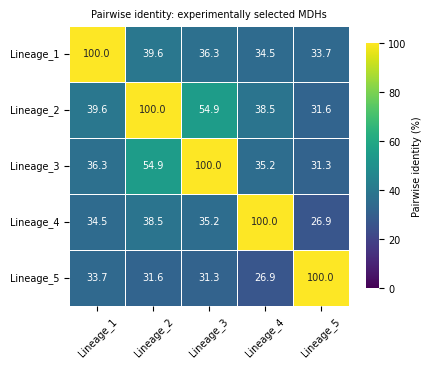

In [23]:
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Plot settings
size_mm = (75*1.5, 65*1.5)  # width, height in millimetres
font_size = 7

distance_path = Path('../Results/Statements/WT_MDH_Experiment.dist')
distance_matrix = pd.read_csv(
    distance_path,
    sep=r'\s+',
    skiprows=1,
    header=None,
    index_col=0,
)
distance_matrix.index.name = 'sequence'
distance_matrix.columns = distance_matrix.index

identity_matrix = (1 - distance_matrix) * 100
identity_matrix.to_csv(
    '../Results/Statements/WT_MDH_Experiment_identity_matrix.csv'
)
off_diagonal = ~np.eye(len(identity_matrix), dtype=bool)
unique_pairs = np.triu(np.ones(identity_matrix.shape, dtype=bool), k=1)

mean_identity_by_sequence = pd.DataFrame({
    'mean_identity_percent': identity_matrix.where(off_diagonal).mean(axis=1),
})
overall_mean_identity = identity_matrix.to_numpy()[unique_pairs].mean()

display(mean_identity_by_sequence.round(2))
print(f'Overall mean identity across {unique_pairs.sum()} unique pairs: '
      f'{overall_mean_identity:.2f}%')

mean_identity_by_sequence.to_csv(
    '../Results/Statements/WT_MDH_Experiment_mean_identity.csv'
)

fig, ax = plt.subplots(figsize=tuple(value / 25.4 for value in size_mm))
sns.heatmap(
    identity_matrix,
    annot=True,
    annot_kws={'fontsize': font_size},
    fmt='.1f',
    cmap='viridis',
    vmin=0,
    vmax=100,
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Pairwise identity (%)', 'shrink': 0.8},
    ax=ax,
)
ax.set_title(
    'Pairwise identity: experimentally selected MDHs',
    fontsize=font_size,
)
ax.set_xlabel('', fontsize=font_size)
ax.set_ylabel('', fontsize=font_size)
ax.tick_params(axis='x', rotation=45, labelsize=font_size)
ax.tick_params(axis='y', rotation=0, labelsize=font_size)
colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=font_size)
colorbar.set_label('Pairwise identity (%)', fontsize=font_size)
fig.tight_layout()
fig.savefig(
    '../Results/Statements/WT_MDH_Experiment_identity_heatmap.pdf',
    bbox_inches='tight',
)
plt.show()